# utils_frozenlake.py — smoke test

Runs every tabular helper once. If all cells execute and the plots/video look right, the module is good to use in the course notebooks.

```python
from utils_frozenlake import plot_policy, plot_values, plot_action_values, test_agent
```

In [1]:
%pip install -qq gymnasium==1.3.0 pygame seaborn

import gymnasium as gym
import numpy as np
from utils_frozenlake import (plot_values, plot_policy, plot_action_values,
                              plot_tabular_cost_to_go, test_agent, test_env,
                              evaluate_policy, seed_everything)

Note: you may need to restart the kernel to use updated packages.


Solve the lake with value iteration to get realistic V and Q tables to plot:

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
seed_everything(env, 42)

# Value iteration (compact form; see Section 3 notebook for the teaching version).
P, nS, nA, gamma = env.unwrapped.P, 16, 4, 0.99
V, policy_probs = np.zeros(nS), np.full((nS, nA), 1/nA)
delta = np.inf
while delta > 1e-8:
    delta = 0
    for s in range(nS):
        old = V[s]
        qsa = [sum(p*(r + gamma*V[sn]) for p, sn, r, t in P[s][a]) for a in range(nA)]
        best = int(np.argmax(qsa)); V[s] = qsa[best]
        policy_probs[s] = np.eye(nA)[best]
        delta = max(delta, abs(V[s] - old))

Q = np.array([[sum(p*(r + gamma*V[sn]) for p, sn, r, t in P[s][a]) for a in range(nA)] for s in range(nS)])

C:\Anaconda\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


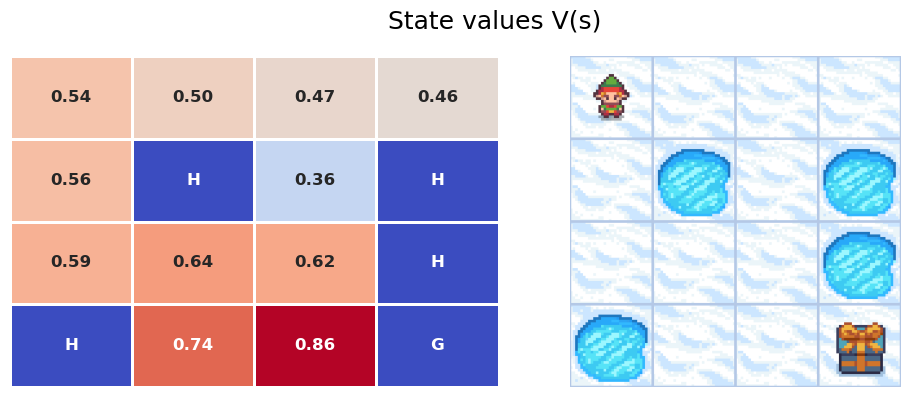

In [3]:
frame = env.render()
plot_values(V, frame=frame, env=env)          # V(s) heatmap, holes/gift lettered

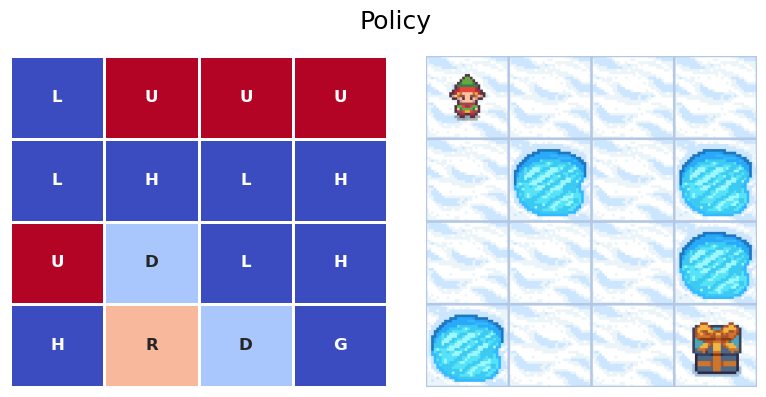

In [4]:
plot_policy(policy_probs, frame=frame, env=env)   # greedy letters (also accepts a Q table)

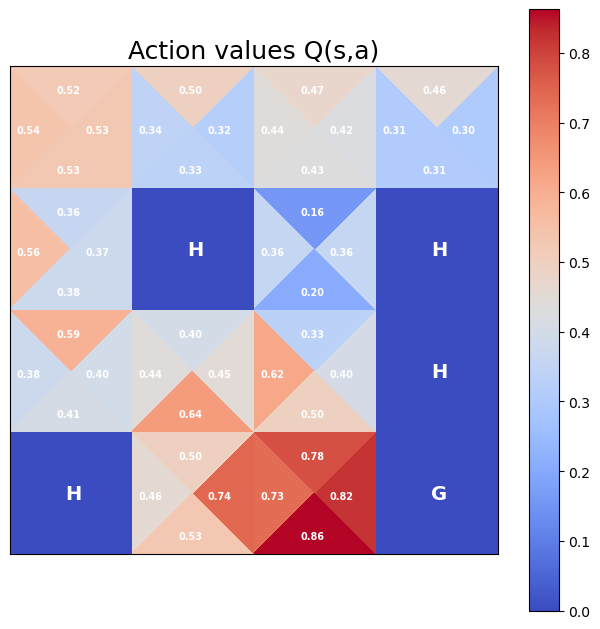

In [5]:
plot_action_values(Q, env=env)                # all four Q(s,a) per tile (quatromatrix)

In [6]:
print(f"Success rate of the optimal policy: {evaluate_policy(env, lambda s: policy_probs[s]):.1%}")

Success rate of the optimal policy: 72.4%


In [7]:
test_agent(env, lambda s: policy_probs[s], episodes=3)   # watch it play

In [8]:
env.close()